# Naive Bayes from Scratch (Pure Python + Pandas)
Multinomial Naive Bayes for tweet sentiment — no numpy, no sklearn.
Trained model is saved to `../Models/naive_bayes_scratch.json`.

## 1. Load & Preprocess Tweets

In [1]:
import nltk
nltk.download('twitter_samples', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.corpus import twitter_samples, stopwords
import pandas as pd
import re, math, json, os
from collections import Counter

STOPWORDS = set(stopwords.words('english'))

def clean(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return [t for t in text.split() if t not in STOPWORDS and len(t) > 1]

pos = twitter_samples.strings('positive_tweets.json')
neg = twitter_samples.strings('negative_tweets.json')

df = pd.DataFrame(
    [(clean(t), 1) for t in pos] + [(clean(t), 0) for t in neg],
    columns=['tokens', 'label']
)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Total: {len(df):,}  |  Pos: {df.label.sum():,}  |  Neg: {(df.label==0).sum():,}")
df.head(3)

Total: 10,000  |  Pos: 5,000  |  Neg: 5,000


,tokens,label
0,"[love, feel, emm, think]",0
1,"[thanks, guys]",1
2,"[love, lord, better, life, lt]",1


## 2. Train / Test Split (80/20)

In [2]:
split    = int(len(df) * 0.8)
train_df = df.iloc[:split].reset_index(drop=True)
test_df  = df.iloc[split:].reset_index(drop=True)
print(f"Train: {len(train_df):,}  |  Test: {len(test_df):,}")

Train: 8,000  |  Test: 2,000


## 3. Build Vocabulary

In [3]:
VOCAB_SIZE = 5000

all_tokens = [tok for tokens in train_df['tokens'] for tok in tokens]
vocab      = [w for w, _ in Counter(all_tokens).most_common(VOCAB_SIZE)]
vocab_set  = set(vocab)

print(f"Vocabulary size: {len(vocab):,}")

Vocabulary size: 5,000


## 4. Multinomial Naive Bayes — Training

**Class prior:**
$$P(c) = \frac{N_c}{N}$$

**Word likelihood with Laplace smoothing** (avoids zero probability for unseen words):
$$P(w \mid c) = \frac{\text{count}(w, c) + 1}{\sum_{w'} \text{count}(w', c) + |V|}$$

**Prediction** — pick the class with the highest log posterior:
$$\hat{c} = \arg\max_c \left[ \log P(c) + \sum_{w \in d} \log P(w \mid c) \right]$$

We work in log-space throughout to avoid floating-point underflow from multiplying
many small probabilities together.

In [4]:
def train_naive_bayes(train_df, vocab, vocab_set):
    classes  = [0, 1]
    N        = len(train_df)
    V        = len(vocab)

    log_prior      = {}    # log P(c)
    word_counts    = {}    # raw counts per class
    log_likelihood = {}    # log P(w | c)

    for c in classes:
        docs_c = train_df[train_df['label'] == c]['tokens']
        N_c    = len(docs_c)
        log_prior[c] = math.log(N_c / N)

        # Aggregate all word counts for this class
        cnt = Counter(tok for tokens in docs_c for tok in tokens if tok in vocab_set)
        total_c = sum(cnt.values())

        word_counts[c] = cnt
        log_likelihood[c] = {
            w: math.log((cnt.get(w, 0) + 1) / (total_c + V))
            for w in vocab
        }
        # Pre-compute the log-likelihood for an unseen word (OOV)
        log_likelihood[c]['<OOV>'] = math.log(1 / (total_c + V))

    return log_prior, log_likelihood


log_prior, log_likelihood = train_naive_bayes(train_df, vocab, vocab_set)

print(f"log P(positive) = {log_prior[1]:.4f}  →  P = {math.exp(log_prior[1]):.4f}")
print(f"log P(negative) = {log_prior[0]:.4f}  →  P = {math.exp(log_prior[0]):.4f}")

log P(positive) = -0.6882  →  P = 0.5025
log P(negative) = -0.6982  →  P = 0.4975


## 5. Prediction

In [5]:
def predict_one(tokens, log_prior, log_likelihood, classes=[0, 1]):
    scores = {}
    for c in classes:
        score = log_prior[c]
        for w in tokens:
            score += log_likelihood[c].get(w, log_likelihood[c]['<OOV>'])
        scores[c] = score
    return max(scores, key=scores.get), scores

def predict_all(token_lists, log_prior, log_likelihood):
    preds = []
    probs = []
    for tokens in token_lists:
        label, scores = predict_one(tokens, log_prior, log_likelihood)
        preds.append(label)
        # Convert log-scores to probabilities via softmax over two classes
        s0, s1   = scores[0], scores[1]
        max_s    = max(s0, s1)
        e0, e1   = math.exp(s0 - max_s), math.exp(s1 - max_s)
        probs.append(e1 / (e0 + e1))
    return preds, probs

y_pred_test, y_prob_test = predict_all(test_df['tokens'].tolist(), log_prior, log_likelihood)
print(f"Sample predictions (first 5): {y_pred_test[:5]}")

Sample predictions (first 5): [0, 1, 0, 1, 1]


## 6. Evaluation

In [6]:
import matplotlib.pyplot as plt

y_true = test_df['label'].tolist()

def eval_metrics(y_true, y_pred, label='Test'):
    tp = sum(1 for a, b in zip(y_true, y_pred) if a==1 and b==1)
    tn = sum(1 for a, b in zip(y_true, y_pred) if a==0 and b==0)
    fp = sum(1 for a, b in zip(y_true, y_pred) if a==0 and b==1)
    fn = sum(1 for a, b in zip(y_true, y_pred) if a==1 and b==0)
    acc  = (tp+tn) / len(y_true)
    prec = tp/(tp+fp) if (tp+fp) > 0 else 0
    rec  = tp/(tp+fn) if (tp+fn) > 0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
    print(f"{label} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")
    return dict(Accuracy=acc, Precision=prec, Recall=rec, F1=f1)

y_pred_train, _ = predict_all(train_df['tokens'].tolist(), log_prior, log_likelihood)
eval_metrics(train_df['label'].tolist(), y_pred_train, 'Train')
eval_metrics(y_true, y_pred_test, 'Test')

Train | Acc: 0.8466 | Prec: 0.8717 | Rec: 0.8147 | F1: 0.8422
Test | Acc: 0.7535 | Prec: 0.7697 | Rec: 0.7092 | F1: 0.7382


{'Accuracy': 0.7535,
 'Precision': 0.769656699889258,
 'Recall': 0.7091836734693877,
 'F1': 0.7381837493361657}

## 7. Confusion Matrix

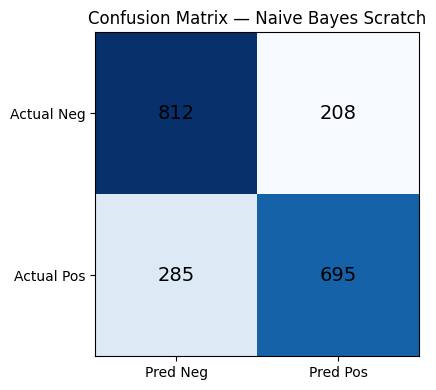

,Pred Neg,Pred Pos
Actual Neg,812,208
Actual Pos,285,695


In [7]:
cm = [[0, 0], [0, 0]]
for a, b in zip(y_true, y_pred_test):
    cm[a][b] += 1
cm_df = pd.DataFrame(cm, index=['Actual Neg', 'Actual Pos'],
                     columns=['Pred Neg', 'Pred Pos'])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred Neg', 'Pred Pos'])
ax.set_yticklabels(['Actual Neg', 'Actual Pos'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i][j], ha='center', va='center', fontsize=14)
ax.set_title('Confusion Matrix — Naive Bayes Scratch')
plt.tight_layout(); plt.show()
cm_df

## 8. Top Discriminative Words

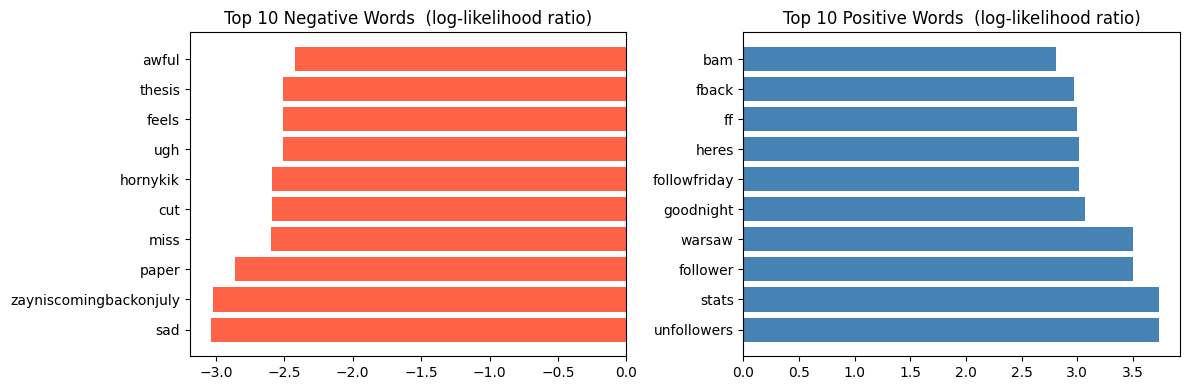

In [8]:
# Words where P(w|pos) - P(w|neg) is most extreme
scores_word = [
    (w, log_likelihood[1][w] - log_likelihood[0][w])
    for w in vocab
]
scores_word.sort(key=lambda x: x[1])

top_neg = scores_word[:10]
top_pos = scores_word[-10:][::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.barh([w for w,_ in top_neg], [s for _,s in top_neg], color='tomato')
ax1.set_title('Top 10 Negative Words  (log-likelihood ratio)')
ax2.barh([w for w,_ in top_pos], [s for _,s in top_pos], color='steelblue')
ax2.set_title('Top 10 Positive Words  (log-likelihood ratio)')
plt.tight_layout(); plt.show()

## 9. Predict on Custom Tweets

In [9]:
def predict_tweet(tweet):
    tokens         = clean(tweet)
    label, scores  = predict_one(tokens, log_prior, log_likelihood)
    s0, s1         = scores[0], scores[1]
    max_s          = max(s0, s1)
    e0, e1         = math.exp(s0 - max_s), math.exp(s1 - max_s)
    prob           = e1 / (e0 + e1)
    sentiment      = 'Positive 😊' if label == 1 else 'Negative 😞'
    print(f"Tweet:       {tweet}")
    print(f"Probability: {prob:.4f}")
    print(f"Sentiment:   {sentiment}")
    print()

predict_tweet("I love this so much, absolutely amazing!")
predict_tweet("This is the worst day ever, I hate everything.")

Tweet:       I love this so much, absolutely amazing!
Probability: 0.7979
Sentiment:   Positive 😊

Tweet:       This is the worst day ever, I hate everything.
Probability: 0.0332
Sentiment:   Negative 😞



## 10. Save Model to `../Models/`

Saves vocabulary, log priors, and log likelihoods as a JSON file
so the model can be reloaded without retraining.

In [10]:
model_data = {
    'vocab':          vocab,
    'log_prior':      {str(k): v for k, v in log_prior.items()},
    'log_likelihood': {
        str(c): log_likelihood[c]
        for c in log_likelihood
    }
}

save_path = '../Models/naive_bayes_scratch.json'
with open(save_path, 'w') as f:
    json.dump(model_data, f)

size_kb = os.path.getsize(save_path) / 1024
print(f"Model saved → {save_path}  ({size_kb:.1f} KB)")

Model saved → ../Models/naive_bayes_scratch.json  (345.0 KB)


## 11. Reload & Verify

In [11]:
with open('../Models/naive_bayes_scratch.json') as f:
    loaded = json.load(f)

vocab_r      = loaded['vocab']
log_prior_r  = {int(k): v for k, v in loaded['log_prior'].items()}
log_like_r   = {int(k): v for k, v in loaded['log_likelihood'].items()}

print("Reloaded model — spot check:")
predict_tweet("I love this so much, absolutely amazing!")

Reloaded model — spot check:
Tweet:       I love this so much, absolutely amazing!
Probability: 0.7979
Sentiment:   Positive 😊

